In [1]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [2]:
import os
import gc
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.optimizers import Adam, Adamax, Nadam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import shutil
import glob

from optuna.trial import TrialState

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    BackupAndRestore
)

2026-06-23 10:28:34.924002: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782210515.118176      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782210515.180358      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782210515.631592      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782210515.631646      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782210515.631650      23 computation_placer.cc:177] computation placer alr

In [3]:
# ==========================================
# Library Dasar
# ==========================================
import gc
import os
import json
import pickle
import joblib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# Scikit-Learn
# ==========================================
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================
# TensorFlow / Keras
# ==========================================
import tensorflow as tf
import tensorflow.keras.backend as K

from tensorflow.keras.models import (
    Sequential,
    load_model
)

from tensorflow.keras.layers import (
    ConvLSTM2D,
    BatchNormalization,
    Conv2D
)

from tensorflow.keras.optimizers import Adam, Adamax, Nadam, RMSprop

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ==========================================
# Optuna
# ==========================================
import optuna

In [4]:
def winsorized_var(ds, var, persentil=99.5):
    if var not in ds.data_vars:
        raise ValueError(f"Variabel '{var}' tidak ditemukan di dataset.")

    # Ambil DataArray asli
    da = ds[var]

    # Copy data ke numpy array
    data = da.values.copy()

    # Mask data valid
    valid_mask = np.isfinite(data)

    if valid_mask.sum() == 0:
        raise ValueError(f"Tidak ada data valid pada variabel '{var}'.")

    # Total data
    total_data_semua = data.size
    total_data_valid = int(valid_mask.sum())

    # Hitung persentil dari data valid
    batas_persentil = np.nanpercentile(data[valid_mask], persentil)

    # Hitung jumlah data yang lebih besar dari batas persentil
    outlier_mask = valid_mask & (data > batas_persentil)
    n_outlier = int(outlier_mask.sum())

    # Persentase outlier
    persen_dari_semua_data = (n_outlier / total_data_semua) * 100
    persen_dari_data_valid = (n_outlier / total_data_valid) * 100

    # Statistik sebelum winsorized
    max_before = float(np.nanmax(data[valid_mask]))
    min_before = float(np.nanmin(data[valid_mask]))
    mean_before = float(np.nanmean(data[valid_mask]))
    std_before = float(np.nanstd(data[valid_mask]))

    # Lakukan winsorized
    data[outlier_mask] = batas_persentil

    # Statistik sesudah winsorized
    valid_after = np.isfinite(data)
    max_after = float(np.nanmax(data[valid_after]))
    min_after = float(np.nanmin(data[valid_after]))
    mean_after = float(np.nanmean(data[valid_after]))
    std_after = float(np.nanstd(data[valid_after]))

    # Ganti langsung nilai pada variabel yang sama
    attrs_lama = da.attrs.copy()

    ds[var] = xr.DataArray(
        data,
        dims=da.dims,
        coords=da.coords,
        attrs=attrs_lama,
        name=var
    )

    ds[var].attrs["winsorized"] = "True"
    ds[var].attrs["winsorized_percentile"] = persentil
    ds[var].attrs["winsorized_upper_value"] = float(batas_persentil)
    ds[var].attrs["n_values_above_percentile_replaced"] = n_outlier
    ds[var].attrs["percentage_above_percentile_from_all_data"] = float(persen_dari_semua_data)
    ds[var].attrs["percentage_above_percentile_from_valid_data"] = float(persen_dari_data_valid)

    print("=== WINSORIZED SELESAI ===")
    print(f"Variabel                          : {var}")
    print(f"Persentil                         : P{persentil}")
    print(f"Nilai batas persentil             : {batas_persentil}")
    print("")
    print(f"Total seluruh data                : {total_data_semua}")
    print(f"Total data valid                  : {total_data_valid}")
    print(f"Jumlah data diatas persentil      : {n_outlier}")
    print(f"Persentase dari seluruh data      : {persen_dari_semua_data:.6f}%")
    print(f"Persentase dari data valid        : {persen_dari_data_valid:.6f}%")
    print("")
    print("Sebelum winsorized:")
    print(f"  Minimum                         : {min_before}")
    print(f"  Maximum                         : {max_before}")
    print(f"  Mean                            : {mean_before}")
    print(f"  Std                             : {std_before}")
    print("")
    print("Sesudah winsorized:")
    print(f"  Minimum                         : {min_after}")
    print(f"  Maximum                         : {max_after}")
    print(f"  Mean                            : {mean_after}")
    print(f"  Std                             : {std_after}")

    return ds

# Load Dataset

In [5]:
ds_clean1 = xr.open_dataset('/kaggle/input/notebooks/andreh19/3-1-3d-dineof/ds_wpp_3d_clean.nc')
ds_clean1

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 505, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time              (time) datetime64[ns] 4kB 2014-01-01 ... 2025-01-01
  * lat               (lat) float32 2kB 6.979 6.938 6.896 ... -9.938 -9.979
  * lon               (lon) float32 2kB 90.02 90.06 90.1 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a           (time, lat, lon) float32 356MB ...
    palette           (time, rgb, eightbitcolor) uint8 388kB ...
    chlor_a_3ddineof  (time, lat, lon) float64 712MB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

In [6]:
# masking koordinat
with np.load('/kaggle/input/notebooks/andreh19/2-masking/mask_wpp572.npz') as data:
    mask_2d = data['mask_2d']
    lons = data['lons']
    lats = data['lats']

mask_2d

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(408, 432))

# Outlier Handling

In [7]:
ds_clean = winsorized_var(
    ds=ds_clean1,
    var="chlor_a_3ddineof",
    persentil=99.5
)

=== WINSORIZED SELESAI ===
Variabel                          : chlor_a_3ddineof
Persentil                         : P99.5
Nilai batas persentil             : 2.8669129526615436

Total seluruh data                : 89009280
Total data valid                  : 22247270
Jumlah data diatas persentil      : 111237
Persentase dari seluruh data      : 0.124972%
Persentase dari data valid        : 0.500003%

Sebelum winsorized:
  Minimum                         : 1.998536491984959e-05
  Maximum                         : 1212.8475976762763
  Mean                            : 0.21444409445063026
  Std                             : 0.6775673790689369

Sesudah winsorized:
  Minimum                         : 1.998536491984959e-05
  Maximum                         : 2.8669129526615436
  Mean                            : 0.1990759647453314
  Std                             : 0.3076487759628932


# Scalling (Mix-Max Scaller)

In [8]:
def scalling(ds_bersih, mask_2d, var_name='chlor_a'):    
    ds_scaled = ds_bersih.copy(deep=True)
    chl_3d = ds_scaled[var_name].values
    
    # 1. EKSTRAK HANYA DATA VALID (Abaikan NaN di luar WPP)
    chl_inside = chl_3d[:, mask_2d] 
    
    # 2. LOG-TRANSFORM (Menjinakkan rentang ekstrem klorofil)
    chl_safe = np.where(chl_inside <= 0, 1e-5, chl_inside)
    chl_log = np.log10(chl_safe)
    
    # 3. SCIKIT-LEARN MIN-MAX SCALER
    scaler = MinMaxScaler()
    
    # Ubah ke 1D memanjang agar sklearn menghitung Global Min-Max
    chl_log_1d = chl_log.reshape(-1, 1)
    
    # Fit dan Transform data
    chl_scaled_1d = scaler.fit_transform(chl_log_1d)
    
    # Kembalikan bentuknya ke matriks 2D (waktu x piksel)
    chl_scaled_inside = chl_scaled_1d.reshape(chl_log.shape)
    
    # 4. KEMBALIKAN KE BINGKAI PETA 3D
    # Piksel di luar mask_2d akan tetap dibiarkan NaN seperti aslinya
    chl_3d[:, mask_2d] = chl_scaled_inside
    ds_scaled[var_name].values = chl_3d
    
    # Tampilkan informasi Min Max yang didapat oleh sklearn
    print("Done!!")
    print(f"Info Scaler [Min, Max] asli Log10: {scaler.data_min_[0]:.4f}, {scaler.data_max_[0]:.4f}")
    
    return ds_scaled, scaler

In [9]:
ds_scale, scaler_chl = scalling(ds_clean, mask_2d, var_name='chlor_a_3ddineof')

Done!!
Info Scaler [Min, Max] asli Log10: -4.6993, 0.4574


In [10]:
# save scaller
path_scaler = '/kaggle/working/scaler_klorofil.pkl'
with open(path_scaler, 'wb') as file:
    pickle.dump(scaler_chl, file)
print(f"Objek scikit-learn Scaler berhasil disimpan di: {path_scaler}")

Objek scikit-learn Scaler berhasil disimpan di: /kaggle/working/scaler_klorofil.pkl


# Bounding Box Cropping

In [11]:
baris_valid, kolom_valid = np.where(mask_2d == True)

In [12]:
# Tentukan batas paling ujung (Minimum dan Maksimum)
min_baris, max_baris = np.min(baris_valid), np.max(baris_valid)
min_kolom, max_kolom = np.min(kolom_valid), np.max(kolom_valid)

print(f"Batas Baris (Lat) : {min_baris} sampai {max_baris}")
print(f"Batas Kolom (Lon) : {min_kolom} sampai {max_kolom}")

Batas Baris (Lat) : 14 sampai 380
Batas Kolom (Lon) : 39 sampai 384


In [13]:
ds_train = ds_scale.isel(
    lat=slice(min_baris, max_baris + 1),
    lon=slice(min_kolom, max_kolom + 1)
)

# 4. (PENTING) Potong juga mask_2d agar ukurannya tetap sinkron dengan data baru
mask_2d_cropped = mask_2d[min_baris:max_baris + 1, min_kolom:max_kolom + 1]

# Cek hasil penyusutan memori
print("--- Perbandingan Dimensi ---")
print(f"Bentuk Asli    : {ds_scale.sizes['lat']} x {ds_scale.sizes['lon']}")
print(f"Bentuk Cropped : {ds_train.sizes['lat']} x {ds_train.sizes['lon']}")

--- Perbandingan Dimensi ---
Bentuk Asli    : 408 x 432
Bentuk Cropped : 367 x 346


In [14]:
ds_train

<xarray.Dataset> Size: 770MB
Dimensions:           (time: 505, lat: 367, lon: 346, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time              (time) datetime64[ns] 4kB 2014-01-01 ... 2025-01-01
  * lat               (lat) float32 1kB 6.396 6.354 6.312 ... -8.812 -8.854
  * lon               (lon) float32 1kB 91.65 91.69 91.73 ... 105.9 106.0 106.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a           (time, lat, lon) float32 257MB ...
    palette           (time, rgb, eightbitcolor) uint8 388kB ...
    chlor_a_3ddineof  (time, lat, lon) float64 513MB nan nan nan ... nan nan nan
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

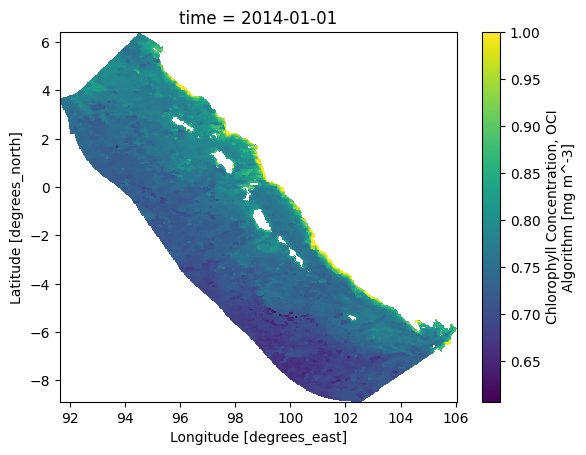

In [15]:
ds_train['chlor_a_3ddineof'].isel(time=0).plot()

# Prepare X, y Input

In [16]:
data_chl_raw = ds_train["chlor_a_3ddineof"].values.astype("float32")

# mask cropped sudah ada dari proses bounding box
mask_inside = mask_2d_cropped.astype("float32")

# broadcast mask ke seluruh waktu
mask_3d = np.broadcast_to(
    mask_inside,
    data_chl_raw.shape
).astype("float32")

# isi NaN luar WPP menjadi 0 untuk channel chlor_a
data_chl = np.nan_to_num(
    data_chl_raw,
    nan=0.0
).astype("float32")

# gabungkan menjadi 2 channel
# channel 0 = chlor_a
# channel 1 = mask WPP
data_input = np.stack(
    [data_chl, mask_3d],
    axis=-1
).astype("float32")

print("Shape data_chl   :", data_chl.shape)
print("Shape mask_3d    :", mask_3d.shape)
print("Shape data_input :", data_input.shape)

Shape data_chl   : (505, 367, 346)
Shape mask_3d    : (505, 367, 346)
Shape data_input : (505, 367, 346, 2)


In [17]:
var_name = "chlor_a_3ddineof"

print("Shape data_chl:", data_chl.shape)
print("Jumlah NaN setelah fill:", np.isnan(data_chl).sum())
print("Minimum:", np.nanmin(data_chl))
print("Maximum:", np.nanmax(data_chl))


Shape data_chl: (505, 367, 346)
Jumlah NaN setelah fill: 0
Minimum: 0.0
Maximum: 1.0


In [18]:
def create_sequences_grid_masked(data_input, time_steps=3):
    """
    Membuat sequence ConvLSTM dari data 4D:
    time, lat, lon, channel

    channel 0 = chlor_a
    channel 1 = mask WPP

    X shape = sample, time_steps, lat, lon, channel
    y shape = sample, lat, lon, 1
    """

    X = []
    y = []

    n_time = data_input.shape[0]

    for i in range(n_time - time_steps):
        X.append(data_input[i:i + time_steps])

        # target hanya chlor_a, bukan mask
        y_target = data_input[i + time_steps, :, :, 0]
        y.append(y_target[..., np.newaxis])

    X = np.array(X, dtype="float32")
    y = np.array(y, dtype="float32")

    return X, y

In [19]:
time_steps = 3

X_seq, y_seq = create_sequences_grid_masked(
    data_input,
    time_steps=time_steps
)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (502, 3, 367, 346, 2)
y_seq shape: (502, 367, 346, 1)


# Splitting

In [20]:
time_index = ds_train.time.values
dates = pd.to_datetime(time_index[time_steps:])
dates

DatetimeIndex(['2014-01-25', '2014-02-02', '2014-02-10', '2014-02-18',
               '2014-02-26', '2014-03-06', '2014-03-14', '2014-03-22',
               '2014-03-30', '2014-04-07',
               ...
               '2024-10-23', '2024-10-31', '2024-11-08', '2024-11-16',
               '2024-11-24', '2024-12-02', '2024-12-10', '2024-12-18',
               '2024-12-26', '2025-01-01'],
              dtype='datetime64[ns]', length=502, freq=None)

In [21]:
train_idx = dates < "2024-01-01"
eval_idx = (dates >= "2024-01-01") & (dates <= "2024-06-30")
test_idx = (dates >= "2024-07-01") & (dates <= "2024-12-31")

X_train, y_train = X_seq[train_idx], y_seq[train_idx]
X_eval, y_eval = X_seq[eval_idx], y_seq[eval_idx]
X_test, y_test = X_seq[test_idx], y_seq[test_idx]

print("Jumlah total sequence:", len(X_seq))
print("Jumlah train sequence:", len(X_train))
print("Jumlah eval sequence:", len(X_eval))
print("Jumlah test sequence:", len(X_test))

print("Shape X_train:", X_train.shape)
print("Shape y_train:", y_train.shape)
print("Shape X_eval:", X_eval.shape)
print("Shape y_eval:", y_eval.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_test:", y_test.shape)

Jumlah total sequence: 502
Jumlah train sequence: 455
Jumlah eval sequence: 23
Jumlah test sequence: 23
Shape X_train: (455, 3, 367, 346, 2)
Shape y_train: (455, 367, 346, 1)
Shape X_eval: (23, 3, 367, 346, 2)
Shape y_eval: (23, 367, 346, 1)
Shape X_test: (23, 3, 367, 346, 2)
Shape y_test: (23, 367, 346, 1)


In [22]:
# =====================================================
# SIMPAN DATA SIAP TRAINING
# agar notebook baru tidak perlu preprocessing ulang
# =====================================================

READY_DATA_PATH = "/kaggle/working/convlstm_ready_data.npz"

np.savez_compressed(
    READY_DATA_PATH,
    X_train=X_train,
    y_train=y_train,
    X_eval=X_eval,
    y_eval=y_eval,
    X_test=X_test,
    y_test=y_test
)

print("Data siap training berhasil disimpan di:")
print(READY_DATA_PATH)

Data siap training berhasil disimpan di:
/kaggle/working/convlstm_ready_data.npz


# Fine Tuning Optuna

In [23]:
# Ambil input shape dari X_train

_, time_steps_model, n_lat, n_lon, n_channel = X_train.shape

print("Input shape:", (time_steps_model, n_lat, n_lon, n_channel))

Input shape: (3, 367, 346, 2)


In [24]:
INPUT_SHAPE = (time_steps_model, n_lat, n_lon, n_channel)

In [25]:
WORK_DIR = "/kaggle/working"

LOG_DIR = os.path.join(WORK_DIR, "optuna_logs")
MODEL_DIR = os.path.join(WORK_DIR, "optuna_models")
BACKUP_DIR = os.path.join(WORK_DIR, "optuna_backups")
BEST_DIR = os.path.join(WORK_DIR, "best_optuna_result")

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(BACKUP_DIR, exist_ok=True)
os.makedirs(BEST_DIR, exist_ok=True)

# database Optuna
STUDY_NAME = "convlstm_finetuning"
STORAGE_PATH = os.path.join(WORK_DIR, "optuna_convlstm.db")
STORAGE_NAME = f"sqlite:///{STORAGE_PATH}"

print("LOG_DIR      :", LOG_DIR)
print("MODEL_DIR    :", MODEL_DIR)
print("BACKUP_DIR   :", BACKUP_DIR)
print("BEST_DIR     :", BEST_DIR)
print("STORAGE_PATH :", STORAGE_PATH)

LOG_DIR      : /kaggle/working/optuna_logs
MODEL_DIR    : /kaggle/working/optuna_models
BACKUP_DIR   : /kaggle/working/optuna_backups
BEST_DIR     : /kaggle/working/best_optuna_result
STORAGE_PATH : /kaggle/working/optuna_convlstm.db


In [26]:
class TrialLogger(tf.keras.callbacks.Callback):
    """
    Callback untuk menampilkan log training per epoch.
    """

    def __init__(self, trial_number):
        super().__init__()
        self.trial_number = trial_number

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        loss = logs.get("loss")
        mae = logs.get("mae")
        val_loss = logs.get("val_loss")
        val_mae = logs.get("val_mae")

        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))

        print(
            f"Trial {self.trial_number:03d} | "
            f"Epoch {epoch + 1:02d} | "
            f"loss={loss:.6f} | "
            f"mae={mae:.6f} | "
            f"val_loss={val_loss:.6f} | "
            f"val_mae={val_mae:.6f} | "
            f"lr={lr:.8f}"
        )


def objective(trial):
    K.clear_session()
    gc.collect()

    # =====================================================
    # 1. SEARCH SPACE
    # =====================================================
    batch_size = 2

    kernel_size = trial.suggest_categorical(
        "kernel_size",
        [3, 5]
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "Adamax", "Nadam"]
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-3,
        log=True
    )

    filters_l1 = trial.suggest_categorical(
        "filters_l1",
        [32, 48, 64]
    )

    filters_l2 = trial.suggest_categorical(
        "filters_l2",
        [16, 32, 48]
    )

    filters_l3 = trial.suggest_categorical(
        "filters_l3",
        [8, 16, 24]
    )

    print("\n" + "=" * 80)
    print(f"MEMULAI TRIAL KE-{trial.number}")
    print("=" * 80)
    print(f"kernel_size   : {kernel_size}")
    print(f"optimizer     : {optimizer_name}")
    print(f"learning_rate : {learning_rate}")
    print(f"filters_l1    : {filters_l1}")
    print(f"filters_l2    : {filters_l2}")
    print(f"filters_l3    : {filters_l3}")
    print(f"batch_size    : {batch_size}")
    print("=" * 80)

    # =====================================================
    # 2. OPTIMIZER
    # =====================================================
    if optimizer_name == "Adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == "Adamax":
        opt = Adamax(learning_rate=learning_rate)
    elif optimizer_name == "Nadam":
        opt = Nadam(learning_rate=learning_rate)
    else:
        raise ValueError("Optimizer tidak dikenali.")

    # =====================================================
    # 3. MODEL CONVLSTM
    # =====================================================
    model = Sequential()

    model.add(ConvLSTM2D(
        filters=filters_l1,
        kernel_size=(kernel_size, kernel_size),
        padding="same",
        activation="tanh",
        return_sequences=True,
        input_shape=INPUT_SHAPE
    ))
    model.add(BatchNormalization())

    model.add(ConvLSTM2D(
        filters=filters_l2,
        kernel_size=(kernel_size, kernel_size),
        padding="same",
        activation="tanh",
        return_sequences=True
    ))
    model.add(BatchNormalization())

    model.add(ConvLSTM2D(
        filters=filters_l3,
        kernel_size=(kernel_size, kernel_size),
        padding="same",
        activation="tanh",
        return_sequences=False
    ))
    model.add(BatchNormalization())

    model.add(Conv2D(
        filters=1,
        kernel_size=(3, 3),
        padding="same",
        activation="linear"
    ))

    model.compile(
        optimizer=opt,
        loss="mse",
        metrics=["mae"]
    )

    # =====================================================
    # 4. CALLBACKS
    # =====================================================
    trial_model_path = os.path.join(
    MODEL_DIR,
    f"trial_{trial.number}.keras")
    
    trial_backup_dir = os.path.join(
    BACKUP_DIR,
    f"trial_{trial.number}")

    callbacks = [
        TrialLogger(trial.number),
    
        BackupAndRestore(
            backup_dir=trial_backup_dir,
            save_freq="epoch",
            delete_checkpoint=False
        ),
    
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
    
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),
    
        ModelCheckpoint(
            filepath=trial_model_path,
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        )
    ]

    # =====================================================
    # 5. TRAINING
    # =====================================================
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_eval, y_eval),
        epochs=50,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )

    # =====================================================
    # 6. SIMPAN HISTORY PER TRIAL
    # =====================================================
    df_history = pd.DataFrame(history.history)
    df_history.insert(0, "epoch", np.arange(1, len(df_history) + 1))
    df_history.insert(0, "trial", trial.number)

    df_history["kernel_size"] = kernel_size
    df_history["optimizer"] = optimizer_name
    df_history["learning_rate"] = learning_rate
    df_history["filters_l1"] = filters_l1
    df_history["filters_l2"] = filters_l2
    df_history["filters_l3"] = filters_l3
    df_history["batch_size"] = batch_size

    history_path = os.path.join(
        LOG_DIR,
        f"history_trial_{trial.number}.csv"
    )

    df_history.to_csv(history_path, index=False)

    # =====================================================
    # 7. AMBIL METRIK TERBAIK
    # =====================================================
    val_loss_terbaik = float(np.min(history.history["val_loss"]))
    epoch_terbaik = int(np.argmin(history.history["val_loss"]) + 1)
    val_mae_terbaik = float(history.history["val_mae"][epoch_terbaik - 1])

    train_loss_epoch_terbaik = float(history.history["loss"][epoch_terbaik - 1])
    train_mae_epoch_terbaik = float(history.history["mae"][epoch_terbaik - 1])

    # simpan atribut ke Optuna
    trial.set_user_attr("epoch_terbaik", epoch_terbaik)
    trial.set_user_attr("train_loss_epoch_terbaik", train_loss_epoch_terbaik)
    trial.set_user_attr("train_mae_epoch_terbaik", train_mae_epoch_terbaik)
    trial.set_user_attr("val_loss_terbaik", val_loss_terbaik)
    trial.set_user_attr("val_mae_terbaik", val_mae_terbaik)
    trial.set_user_attr("history_path", history_path)
    trial.set_user_attr("model_path", trial_model_path)

    # =====================================================
    # 8. SIMPAN RINGKASAN TRIAL
    # =====================================================
    summary_trial = {
        "trial": trial.number,
        "epoch_terbaik": epoch_terbaik,
        "train_loss_epoch_terbaik": train_loss_epoch_terbaik,
        "train_mae_epoch_terbaik": train_mae_epoch_terbaik,
        "val_loss_terbaik": val_loss_terbaik,
        "val_mae_terbaik": val_mae_terbaik,
        "kernel_size": kernel_size,
        "optimizer": optimizer_name,
        "learning_rate": learning_rate,
        "filters_l1": filters_l1,
        "filters_l2": filters_l2,
        "filters_l3": filters_l3,
        "batch_size": batch_size,
        "history_path": history_path,
        "model_path": trial_model_path
    }

    summary_path = os.path.join(LOG_DIR, "optuna_trial_summary.csv")

    if os.path.exists(summary_path):
        df_summary_lama = pd.read_csv(summary_path)
        df_summary_baru = pd.concat(
            [df_summary_lama, pd.DataFrame([summary_trial])],
            ignore_index=True
        )
    else:
        df_summary_baru = pd.DataFrame([summary_trial])

    df_summary_baru.to_csv(summary_path, index=False)

    print("\n" + "-" * 80)
    print(f"SELESAI TRIAL KE-{trial.number}")
    print(f"Epoch terbaik      : {epoch_terbaik}")
    print(f"Train loss terbaik : {train_loss_epoch_terbaik:.6f}")
    print(f"Train MAE terbaik  : {train_mae_epoch_terbaik:.6f}")
    print(f"Val loss terbaik   : {val_loss_terbaik:.6f}")
    print(f"Val MAE terbaik    : {val_mae_terbaik:.6f}")
    print(f"History disimpan   : {history_path}")
    print(f"Model disimpan     : {trial_model_path}")
    print("-" * 80)

    return val_loss_terbaik

In [27]:
# =====================================================
# EKSEKUSI OPTUNA DENGAN RESUME
# =====================================================

print("--- Memulai atau Melanjutkan Tuning Optuna ---")

study = optuna.create_study(
    study_name=STUDY_NAME,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    storage=STORAGE_NAME,
    load_if_exists=True
)

# target total trial yang diinginkan
TARGET_TOTAL_TRIALS = 50

# jumlah trial maksimal untuk sesi Kaggle saat ini
# gunakan kecil dulu agar aman dari limit 12 jam
MAX_TRIALS_THIS_SESSION = 10

completed_trials = [
    t for t in study.trials
    if t.state == TrialState.COMPLETE
]

n_completed = len(completed_trials)
remaining_trials = TARGET_TOTAL_TRIALS - n_completed
n_trials_this_session = min(MAX_TRIALS_THIS_SESSION, remaining_trials)

print("Jumlah trial selesai sebelumnya :", n_completed)
print("Target total trial              :", TARGET_TOTAL_TRIALS)
print("Sisa trial                      :", remaining_trials)
print("Trial yang dijalankan sesi ini  :", n_trials_this_session)

if n_trials_this_session > 0:
    study.optimize(
        objective,
        n_trials=n_trials_this_session,
        show_progress_bar=True
    )
else:
    print("Semua target trial sudah selesai.")

--- Memulai atau Melanjutkan Tuning Optuna ---


[I 2026-06-23 10:30:02,708] A new study created in RDB with name: convlstm_finetuning


Jumlah trial selesai sebelumnya : 0
Target total trial              : 50
Sisa trial                      : 50
Trial yang dijalankan sesi ini  : 10


  0%|          | 0/10 [00:00<?, ?it/s]


MEMULAI TRIAL KE-0
kernel_size   : 5
optimizer     : Adam
learning_rate : 0.00014321698289111514
filters_l1    : 48
filters_l2    : 48
filters_l3    : 8
batch_size    : 2


...

Trial 007 | Epoch 01 | loss=0.047779 | mae=0.158918 | val_loss=0.151238 | val_mae=0.373296 | lr=0.00019487

Epoch 1: val_loss improved from None to 0.15124, saving model to /kaggle/working/optuna_models/trial_7.keras

Epoch 1: finished saving model to /kaggle/working/optuna_models/trial_7.keras
Trial 007 | Epoch 02 | loss=0.002196 | mae=0.030579 | val_loss=0.039984 | val_mae=0.144703 | lr=0.00019487

Epoch 2: val_loss improved from 0.15124 to 0.03998, saving model to /kaggle/working/optuna_models/trial_7.keras

Epoch 2: finished saving model to /kaggle/working/optuna_models/trial_7.keras
Trial 007 | Epoch 03 | loss=0.001008 | mae=0.016081 | val_loss=0.004341 | val_mae=0.058430 | lr=0.00019487

Epoch 3: val_loss improved from 0.03998 to 0.00434, saving model to /kaggle/working/optuna_models/trial_7.keras

Epoch 3: finished saving model to /kaggle/working/optuna_models/trial_7.keras
Trial 007 | Epoch 04 | loss=0.000854 | mae=0.015619 | val_loss=0.001068 | val_mae=0.026806 | lr=0.00019487

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Trial 008 | Epoch 01 | loss=0.040918 | mae=0.128524 | val_loss=0.116463 | val_mae=0.308309 | lr=0.00026737

Epoch 1: val_loss improved from None to 0.11646, saving model to /kaggle/working/optuna_models/trial_8.keras

Epoch 1: finished saving model to /kaggle/working/optuna_models/trial_8.keras
Trial 008 | Epoch 02 | loss=0.001747 | mae=0.021568 | val_loss=0.010139 | val_mae=0.053271 | lr=0.00026737

Epoch 2: val_loss improved from 0.11646 to 0.01014, saving model to /kaggle/working/optuna_models/trial_8.keras

Epoch 2: finished saving model to /kaggle/working/optuna_models/trial_8.keras
Trial 008 | Epoch 03 | loss=0.001198 | mae=0.018554 | val_loss=0.002195 | val_mae=0.027859 | lr=0.00026737

Epoch 3: val_loss improved from 0.01014 to 0.00219, saving model to /kaggle/working/optuna_models/trial_8.keras

Epoch 3: finished saving model to /kaggle/working/optuna_models/trial_8.keras
Trial 008 | Epoch 04 | loss=0.000883 | mae=0.016388 | val_loss=0.004555 | val_mae=0.061098 | lr=0.00026737

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Trial 009 | Epoch 01 | loss=0.053990 | mae=0.086840 | val_loss=0.032331 | val_mae=0.140730 | lr=0.00091716

Epoch 1: val_loss improved from None to 0.03233, saving model to /kaggle/working/optuna_models/trial_9.keras

Epoch 1: finished saving model to /kaggle/working/optuna_models/trial_9.keras
Trial 009 | Epoch 02 | loss=0.000821 | mae=0.013939 | val_loss=0.041562 | val_mae=0.195212 | lr=0.00091716

Epoch 2: val_loss did not improve from 0.03233
Trial 009 | Epoch 03 | loss=0.000620 | mae=0.012882 | val_loss=0.002952 | val_mae=0.033645 | lr=0.00091716

Epoch 3: val_loss improved from 0.03233 to 0.00295, saving model to /kaggle/working/optuna_models/trial_9.keras

Epoch 3: finished saving model to /kaggle/working/optuna_models/trial_9.keras
Trial 009 | Epoch 04 | loss=0.000594 | mae=0.012474 | val_loss=0.000912 | val_mae=0.022034 | lr=0.00091716

Epoch 4: val_loss improved from 0.00295 to 0.00091, saving model to /kaggle/working/optuna_models/trial_9.keras

Epoch 4: finished saving mode

In [28]:
# =====================================================
# SIMPAN HASIL TERBAIK OPTUNA
# =====================================================

os.makedirs(BEST_DIR, exist_ok=True)

if len([t for t in study.trials if t.state == TrialState.COMPLETE]) == 0:
    print("Belum ada trial yang selesai. Hasil terbaik belum bisa disimpan.")

else:
    # 1. Simpan best params
    best_params_path = os.path.join(BEST_DIR, "best_params.json")

    with open(best_params_path, "w") as f:
        json.dump(study.best_params, f, indent=4)

    # 2. Simpan informasi best trial
    best_trial = study.best_trial

    best_trial_info = {
        "best_trial_number": best_trial.number,
        "best_value_val_loss": float(study.best_value),
        "best_params": study.best_params,
        "user_attrs": best_trial.user_attrs
    }

    best_trial_info_path = os.path.join(BEST_DIR, "best_trial_info.json")

    with open(best_trial_info_path, "w") as f:
        json.dump(best_trial_info, f, indent=4)

    # 3. Copy best model ke folder final
    best_model_path = best_trial.user_attrs["model_path"]
    final_best_model_path = os.path.join(
        BEST_DIR,
        "best_convlstm_optuna.keras"
    )

    if os.path.exists(best_model_path):
        shutil.copy(best_model_path, final_best_model_path)
    else:
        print("Model terbaik tidak ditemukan:", best_model_path)

    # 4. Simpan dataframe semua trial dari Optuna
    df_optuna_trials = study.trials_dataframe()
    optuna_trials_path = os.path.join(
        BEST_DIR,
        "optuna_trials_dataframe.csv"
    )
    df_optuna_trials.to_csv(optuna_trials_path, index=False)

    # 5. Simpan ringkasan trial manual
    summary_path = os.path.join(LOG_DIR, "optuna_trial_summary.csv")

    if os.path.exists(summary_path):
        df_summary = pd.read_csv(summary_path)
        df_summary_sorted = df_summary.sort_values("val_loss_terbaik")
        df_summary_sorted.to_csv(
            os.path.join(BEST_DIR, "optuna_trial_summary_sorted.csv"),
            index=False
        )

    print("=" * 70)
    print("HASIL OPTUNA BERHASIL DISIMPAN")
    print("=" * 70)
    print(f"Best trial          : {best_trial.number}")
    print(f"Best val loss       : {study.best_value}")
    print(f"Best params         : {study.best_params}")
    print(f"Best params path    : {best_params_path}")
    print(f"Best trial info     : {best_trial_info_path}")
    print(f"Best model path     : {final_best_model_path}")
    print(f"Optuna trials path  : {optuna_trials_path}")
    print("=" * 70)

HASIL OPTUNA BERHASIL DISIMPAN
Best trial          : 2
Best val loss       : 0.0002928554604295641
Best params         : {'kernel_size': 3, 'optimizer': 'Nadam', 'learning_rate': 0.0006432759992849892, 'filters_l1': 64, 'filters_l2': 48, 'filters_l3': 16}
Best params path    : /kaggle/working/best_optuna_result/best_params.json
Best trial info     : /kaggle/working/best_optuna_result/best_trial_info.json
Best model path     : /kaggle/working/best_optuna_result/best_convlstm_optuna.keras
Optuna trials path  : /kaggle/working/best_optuna_result/optuna_trials_dataframe.csv
